In [1]:
import pandas as pd
import os

# Ruta absoluta para que funcione desde cualquier lugar
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("01_eda.ipynb")))
ruta = os.path.join(BASE_DIR, "data", "raw", "ratings_Beauty.csv")

df = pd.read_csv(ruta, 
                 names=["userId", "productId", "rating", "timestamp"],
                 header=0,          # indica que la primera fila es encabezado
                 dtype={"rating": "float32", "timestamp": "int64"},
                 low_memory=False)

print("Primeras 5 filas:")
print(df.head())

print(f"\nForma del dataset: {df.shape}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

print(f"\nTipos de datos:")
print(df.dtypes)

print(f"\nValores nulos:")
print(df.isnull().sum())

print("=== ESTADÍSTICAS DE RATINGS ===")
print(df["rating"].describe())

print(f"\n=== USUARIOS ===")
print(f"Usuarios únicos: {df['userId'].nunique():,}")
print(f"Productos únicos: {df['productId'].nunique():,}")
print(f"Promedio de reseñas por usuario: {df.groupby('userId').size().mean():.2f}")

print(f"\n=== DISTRIBUCIÓN DE RATINGS ===")
print(df["rating"].value_counts().sort_index())

print(f"\n=== USUARIOS MÁS ACTIVOS ===")
print(df.groupby("userId").size().sort_values(ascending=False).head(10))

print(f"\n=== PRODUCTOS MÁS RESEÑADOS ===")
print(df.groupby("productId").size().sort_values(ascending=False).head(10))

Primeras 5 filas:
           userId   productId  rating   timestamp
0  A39HTATAQ9V7YF  0205616461     5.0  1369699200
1  A3JM6GV9MNOF9X  0558925278     3.0  1355443200
2  A1Z513UWSAAO0F  0558925278     5.0  1404691200
3  A1WMRR494NWEWV  0733001998     4.0  1382572800
4  A3IAAVS479H7M7  0737104473     1.0  1274227200

Forma del dataset: (2023070, 4)
Filas: 2,023,070
Columnas: 4

Tipos de datos:
userId           str
productId        str
rating       float32
timestamp      int64
dtype: object

Valores nulos:
userId       0
productId    0
rating       0
timestamp    0
dtype: int64
=== ESTADÍSTICAS DE RATINGS ===
count    2.023070e+06
mean     4.149036e+00
std      1.311505e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

=== USUARIOS ===
Usuarios únicos: 1,210,271
Productos únicos: 249,274
Promedio de reseñas por usuario: 1.67

=== DISTRIBUCIÓN DE RATINGS ===
rating
1.0     183784
2.0     113034


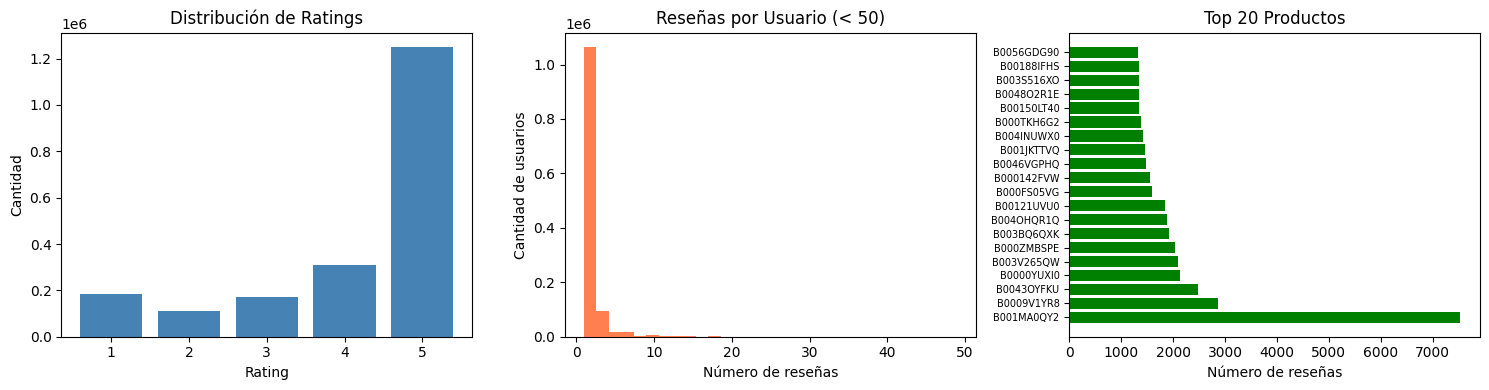


Usuarios únicos: 1,210,271
Productos únicos: 249,274
Promedio reseñas por usuario: 1.67
Rating promedio: 4.15


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfica 1 - Distribución de ratings
rating_counts = df["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color="steelblue")
axes[0].set_title("Distribución de Ratings")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Cantidad")

# Gráfica 2 - Reseñas por usuario (top 50)
reviews_per_user = df.groupby("userId").size().sort_values(ascending=False)
axes[1].hist(reviews_per_user[reviews_per_user < 50], bins=30, color="coral")
axes[1].set_title("Reseñas por Usuario (< 50)")
axes[1].set_xlabel("Número de reseñas")
axes[1].set_ylabel("Cantidad de usuarios")

# Gráfica 3 - Top 20 productos más reseñados
top_productos = df.groupby("productId").size().sort_values(ascending=False).head(20)
axes[2].barh(range(20), top_productos.values, color="green")
axes[2].set_title("Top 20 Productos")
axes[2].set_xlabel("Número de reseñas")
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(top_productos.index, fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "data", "processed", "eda_visualizaciones.png"), dpi=150)
plt.show()

print(f"\nUsuarios únicos: {df['userId'].nunique():,}")
print(f"Productos únicos: {df['productId'].nunique():,}")
print(f"Promedio reseñas por usuario: {reviews_per_user.mean():.2f}")
print(f"Rating promedio: {df['rating'].mean():.2f}")

In [5]:
print("=== ANTES DEL FILTRADO ===")
print(f"Usuarios: {df['userId'].nunique():,}")
print(f"Productos: {df['productId'].nunique():,}")
print(f"Reseñas: {len(df):,}")

# Mantener solo usuarios con al menos 5 reseñas
# y productos con al menos 5 reseñas
MIN_RESEÑAS = 5

usuarios_activos = df.groupby("userId").size()
usuarios_activos = usuarios_activos[usuarios_activos >= MIN_RESEÑAS].index

productos_activos = df.groupby("productId").size()
productos_activos = productos_activos[productos_activos >= MIN_RESEÑAS].index

df_filtrado = df[
    df["userId"].isin(usuarios_activos) & 
    df["productId"].isin(productos_activos)
].copy()

print("\n=== DESPUÉS DEL FILTRADO ===")
print(f"Usuarios: {df_filtrado['userId'].nunique():,}")
print(f"Productos: {df_filtrado['productId'].nunique():,}")
print(f"Reseñas: {len(df_filtrado):,}")
print(f"Reseñas descartadas: {len(df) - len(df_filtrado):,}")

# Guardar dataset filtrado
df_filtrado.to_csv(os.path.join(BASE_DIR, "data", "processed", "ratings_filtrado.csv"), index=False)
print("\n✓ Dataset filtrado guardado en data/processed/")

=== ANTES DEL FILTRADO ===
Usuarios: 1,210,271
Productos: 249,274
Reseñas: 2,023,070

=== DESPUÉS DEL FILTRADO ===
Usuarios: 52,204
Productos: 57,289
Reseñas: 394,908
Reseñas descartadas: 1,628,162

✓ Dataset filtrado guardado en data/processed/
